<a href="https://colab.research.google.com/github/AliBarr18/Data-Mining-Project-Player-Performance/blob/main/Deliverable2_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo
import pandas as pd

dataset = fetch_ucirepo(id=468)
df = dataset.data.features
df['Revenue'] = dataset.data.targets

print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [2]:
# Basic info
print(df.shape)
print("\n")
print(df.dtypes)
print("\n")
print(df.isnull().sum())

(12330, 18)


Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems     

In [3]:
# Summary statistics
print(df.describe())
print("\nClass balance (Revenue):")
print(df['Revenue'].value_counts())

       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%                  0.000000        7.00000

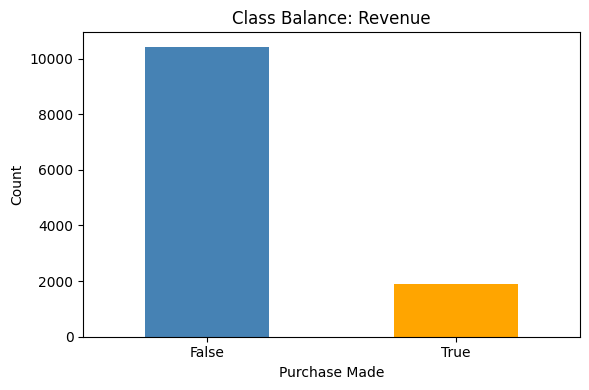

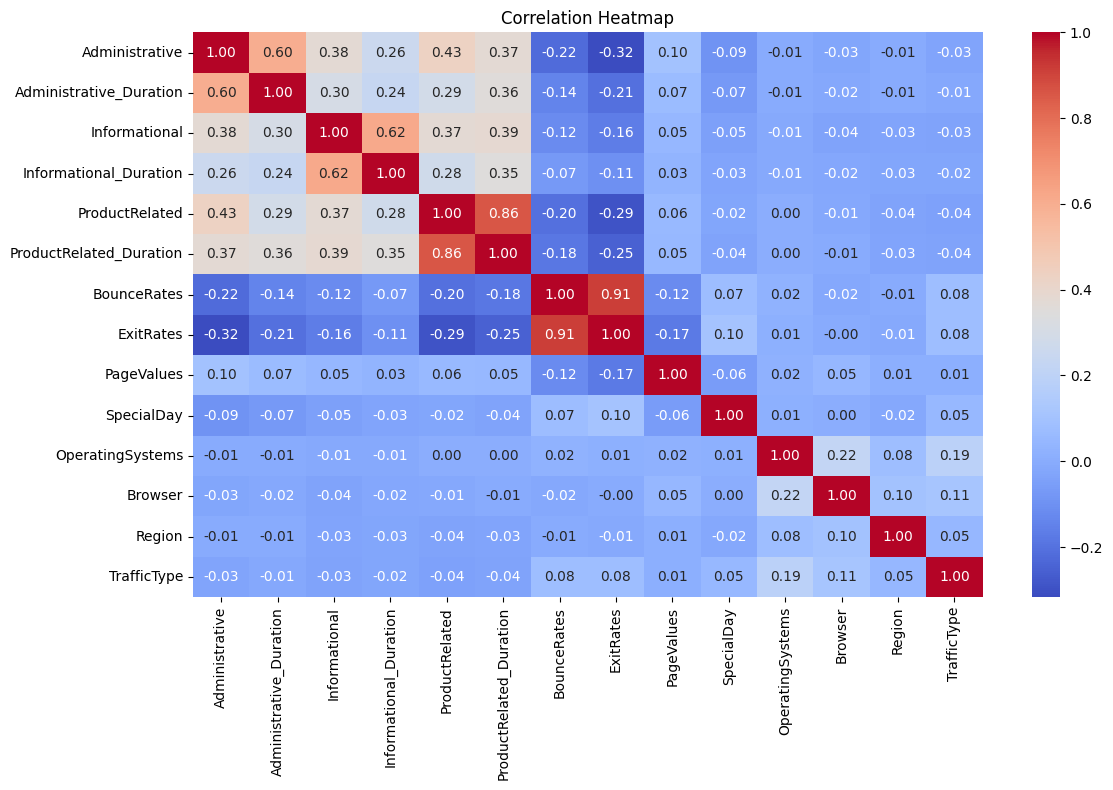

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Class balance
plt.figure(figsize=(6,4))
df['Revenue'].value_counts().plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Class Balance: Revenue')
plt.xlabel('Purchase Made')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 2: Correlation heatmap
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

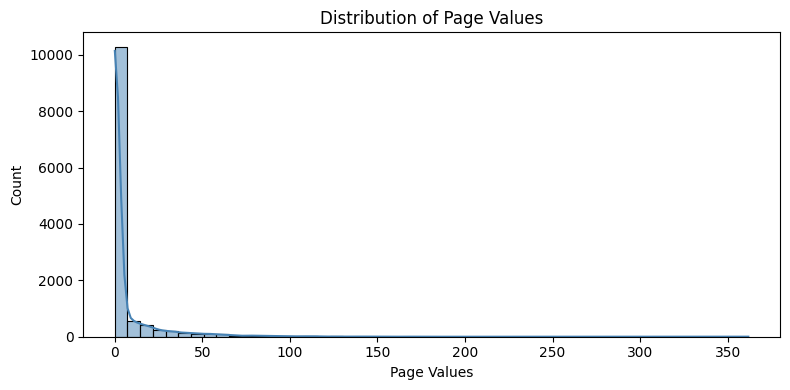

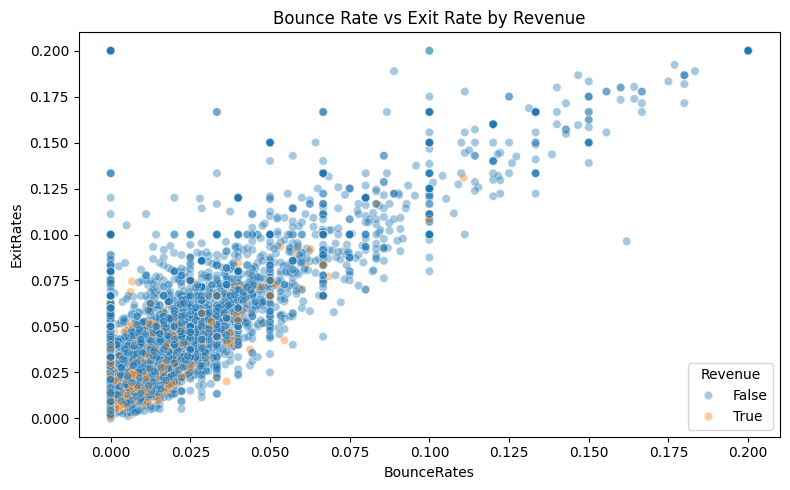

In [5]:
# Plot 3: Distribution of PageValues
plt.figure(figsize=(8,4))
sns.histplot(df['PageValues'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Page Values')
plt.xlabel('Page Values')
plt.tight_layout()
plt.show()

# Plot 4: Bounce Rate vs Exit Rate colored by Revenue
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='BounceRates', y='ExitRates', hue='Revenue', alpha=0.4)
plt.title('Bounce Rate vs Exit Rate by Revenue')
plt.tight_layout()
plt.show()

In [6]:
# Check categorical columns
print("Categorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Convert boolean columns to int
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

print("\nEncoded dataframe shape:", df_encoded.shape)
print("\nAll columns now numeric:")
print(df_encoded.dtypes)

Categorical columns:
['Month', 'VisitorType']

Encoded dataframe shape: (12330, 18)

All columns now numeric:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                  int64
Weekend                      int64
Revenue                      int64
dtype: object


In [7]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nClass balance in training set:")
print(y_train.value_counts())

Training set size: (9864, 17)
Test set size: (2466, 17)

Class balance in training set:
Revenue
0    8338
1    1526
Name: count, dtype: int64
